# Practical No. 02: Text Classification using Embedding Layer and LSTM

## Binary Sentiment Classification of IMDB Movie Reviews

### Student Information

**Name:** Gayatri Gaikwad  
**Course:** Generative AI Lab  
**Practical:** 02  
**Task:** Binary Text Classification  
**Dataset:** IMDB Movie Reviews  
**Model:** Embedding Layer + LSTM Network  
**Framework:** TensorFlow / Keras

---

### Practical Statement

> Build a text classification model for a binary or multiclass classification task using an Embedding layer and an LSTM network. Evaluate the model performance using appropriate classification metrics.

## 1. Objective

The objective of this practical is to develop a deep learning based text classification model using an **Embedding layer and Long Short-Term Memory (LSTM) network**.

In this implementation, the **IMDB Movie Reviews dataset** is used to perform binary sentiment classification.

The model learns to classify a movie review into one of two categories:

- **0 → Negative**
- **1 → Positive**

The practical also evaluates the trained model using multiple classification metrics including:

- Accuracy
- Precision
- Recall
- F1-score
- Binary Cross-Entropy Loss
- Confusion Matrix

In addition to the required evaluation, prediction-confidence analysis, high-confidence error analysis, and an interactive sentiment prediction component are implemented as additional extensions.

## 2. Introduction

Text classification is a fundamental Natural Language Processing (NLP) task in which textual input is automatically assigned to predefined categories.

Examples of text classification include:

- Sentiment analysis
- Spam detection
- News categorization
- Emotion detection
- Toxic comment detection
- Review classification

Traditional machine learning algorithms require text to be converted into numerical features before classification. Deep learning provides another approach in which the model can learn useful representations of text automatically.

In this practical, an **Embedding layer** is used to convert integer word IDs into dense numerical vectors, while an **LSTM network** processes the sequence of word representations and learns contextual information from the review.

The final output is a probability representing the likelihood that the review belongs to the positive sentiment class.

## 3. Problem Definition

### Problem Statement

Given a movie review in textual form, classify its sentiment as either **Negative** or **Positive** using a neural network based on an Embedding layer and LSTM.

### Input

A sequence of words representing an IMDB movie review.

### Output

A binary sentiment label:

| Label | Sentiment |
|---:|---|
| 0 | Negative |
| 1 | Positive |

### Classification Type

This is a **binary classification problem** because there are exactly two output classes.

### Learning Objective

The model should learn patterns and contextual relationships within movie reviews that help distinguish positive opinions from negative opinions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


## 4. Dataset Description

The **IMDB Movie Reviews dataset** is used for this practical. It contains movie reviews labeled according to their sentiment.

The dataset is provided through the TensorFlow/Keras dataset API.

### Dataset Characteristics

- Total training samples: 25,000
- Total testing samples: 25,000
- Number of classes: 2
- Classes: Negative and Positive
- Vocabulary considered in this implementation: 10,000 words

The reviews are already encoded as sequences of integer word IDs, which makes them suitable for direct processing using an Embedding layer.

### Class Labels

- `0` → Negative sentiment
- `1` → Positive sentiment

The test dataset is kept separate from the training process and is used only for final performance evaluation.

## 4.1 Loading the Dataset

The IMDB dataset is loaded using `tf.keras.datasets.imdb.load_data()`.

Only the top **10,000 most frequent words** are considered. Each review is represented as a sequence of integer IDs rather than raw text.

At this stage, the following information is inspected:

- Number of training samples
- Number of testing samples
- Encoded representation of a sample review
- Corresponding sentiment label

In [ ]:
# ============================================================
# Load IMDB Movie Reviews Dataset
# ============================================================

NUM_WORDS = 10000

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(
    num_words=NUM_WORDS
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("First review (encoded):")
print(X_train[0][:20])

print("First label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First review (encoded):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First label: 1


## 5. Review Length Analysis

Movie reviews do not contain the same number of words. Some reviews are short, while others may contain thousands of tokens.

Therefore, the review lengths are analyzed before preparing the data for the LSTM model.

The following statistics are calculated:

- Average review length
- Minimum review length
- Maximum review length

### Observed Dataset Statistics

The average training review length is approximately **238.71 tokens**, while the longest review contains **2494 tokens** and the shortest contains **11 tokens**.

Because neural networks require inputs of a consistent shape within a batch, the reviews must be converted to a common sequence length.

In [ ]:
# ============================================================
# Analyze Review Lengths
# ============================================================

train_lengths = [len(review) for review in X_train]
test_lengths = [len(review) for review in X_test]

print("Average training review length:",
      round(np.mean(train_lengths), 2))

print("Maximum training review length:",
      max(train_lengths))

print("Minimum training review length:",
      min(train_lengths))

Average training review length: 238.71
Maximum training review length: 2494
Minimum training review length: 11


## 6. Sequence Padding and Truncation

Since reviews have different lengths, all sequences are converted to a fixed length of **200 tokens**.

Two operations are performed:

### Padding

Reviews shorter than 200 tokens are filled with zeros until they reach the required length.

### Truncation

Reviews longer than 200 tokens are truncated after the first 200 tokens.

The padding is performed using:

- `padding="post"`
- `truncating="post"`

This produces a consistent input shape of:

**(number of reviews, 200)**

This fixed-length representation can then be provided to the Embedding and LSTM layers.

In [ ]:
# ============================================================
# Padding Sequences
# ============================================================

MAX_LEN = 200

X_train = tf.keras.utils.pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = tf.keras.utils.pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


## 7. Training and Validation Split

The original training dataset is further divided into:

- **20,000 samples → Training**
- **5,000 samples → Validation**

The separate **25,000-sample test set** is preserved for final evaluation.

### Purpose of Each Split

**Training Set:**  
Used to learn the model parameters.

**Validation Set:**  
Used during training to monitor generalization and detect potential overfitting.

**Test Set:**  
Used only after training to measure the final performance of the model on unseen data.

This separation ensures that the final test evaluation is performed on data that was not used for model training.

In [ ]:
# ============================================================
# Train / Validation Split
# ============================================================

VAL_SIZE = 5000

X_val = X_train[:VAL_SIZE]
y_val = y_train[:VAL_SIZE]

X_train_final = X_train[VAL_SIZE:]
y_train_final = y_train[VAL_SIZE:]

print("Training data:", X_train_final.shape)
print("Validation data:", X_val.shape)
print("Test data:", X_test.shape)

Training data: (20000, 200)
Validation data: (5000, 200)
Test data: (25000, 200)


## 8. Model Architecture

The proposed model consists of four main components:

```text
Input Sequence
      ↓
Embedding Layer
      ↓
LSTM Layer
      ↓
Dropout Layer
      ↓
Sigmoid Output

In [ ]:
# ============================================================
# Embedding + LSTM Model
# ============================================================

EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MAX_LEN,)),

    # Convert word IDs into dense word vectors
    tf.keras.layers.Embedding(
        input_dim=NUM_WORDS,
        output_dim=EMBEDDING_DIM
    ),

    # Learn sequential/contextual information
    tf.keras.layers.LSTM(LSTM_UNITS),

    # Reduce overfitting
    tf.keras.layers.Dropout(0.5),

    # Binary classification
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Model Compilation

The model is compiled using the following configuration:

### Optimizer

**Adam optimizer** with a learning rate of `0.001`.

Adam is used to update the network weights during training.

### Loss Function

**Binary Cross-Entropy** is used because the task contains two classes.

Binary cross-entropy measures the difference between the true binary label and the probability predicted by the model.

### Training Metric

**Accuracy** is used during training to monitor the proportion of correctly classified samples.

In [ ]:
# ============================================================
# Compile Model
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 10. Model Training

The model is trained using the prepared training dataset and evaluated on the validation dataset after each epoch.

### Training Configuration

| Parameter | Value |
|---|---:|
| Epochs | 5 |
| Batch Size | 64 |
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Loss Function | Binary Cross-Entropy |
| LSTM Units | 64 |
| Embedding Dimension | 128 |

### Early Stopping

Early stopping is used with validation loss as the monitoring metric.

If the validation loss does not improve for a specified number of epochs, training is stopped and the best model weights are restored.

This helps reduce unnecessary training and limits overfitting.

In [ ]:
# ============================================================
# Training
# ============================================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

EPOCHS = 5
BATCH_SIZE = 64

import time

start_time = time.time()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping]
)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 237ms/step - accuracy: 0.5234 - loss: 0.6912 - val_accuracy: 0.5418 - val_loss: 0.6872
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 237ms/step - accuracy: 0.5516 - loss: 0.6886 - val_accuracy: 0.5976 - val_loss: 0.6505
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 238ms/step - accuracy: 0.6463 - loss: 0.6141 - val_accuracy: 0.5604 - val_loss: 0.6814
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 238ms/step - accuracy: 0.6916 - loss: 0.5510 - val_accuracy: 0.7186 - val_loss: 0.5927
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 238ms/step - accuracy: 0.7841 - loss: 0.4595 - val_accuracy: 0.8064 - val_loss: 0.4543
Training time: 374.16 seconds


## 11. Model Evaluation on Test Data

After training is completed, the model is evaluated on the **unseen test dataset**.

The test set was not used for updating model weights and therefore provides an independent measurement of model performance.

The initial evaluation reports:

- Test Loss
- Test Accuracy

Further evaluation is performed using predictions generated for every test review.

In [ ]:

# ============================================================
# Test Evaluation
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.7959 - loss: 0.4694
Test Loss: 0.46944496035575867
Test Accuracy: 0.7958800196647644


In [ ]:
# ============================================================
# Generate Predictions
# ============================================================

y_prob = model.predict(
    X_test,
    verbose=1
).ravel()

y_pred = (y_prob >= 0.5).astype(int)

print("Predictions generated successfully.")
print("First 10 probabilities:", y_prob[:10])
print("First 10 predictions:", y_pred[:10])
print("First 10 actual labels:", y_test[:10])

## 12. Classification Metrics

To obtain a detailed evaluation of the binary classifier, four standard classification metrics are calculated.

### Accuracy

Accuracy measures the overall proportion of correctly classified reviews.

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

### Precision

Precision measures how many reviews predicted as positive were actually positive.

\[
Precision = \frac{TP}{TP + FP}
\]

### Recall

Recall measures how many of the actual positive reviews were correctly identified.

\[
Recall = \frac{TP}{TP + FN}
\]

### F1-score

The F1-score is the harmonic mean of precision and recall.

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

These metrics provide a more complete view of model performance than accuracy alone.

In [ ]:
# ============================================================
# Classification Metrics
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("LSTM Classification Results")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

LSTM Classification Results
Accuracy : 0.7959
Precision: 0.7747
Recall   : 0.8345
F1-score : 0.8035


## 12.1 Classification Report

The classification report provides precision, recall, F1-score, and support for each class independently.

The two classes evaluated are:

- Negative
- Positive

This allows the performance of the model to be examined separately for both sentiment categories.

In [ ]:
# ============================================================
# Classification Report
# ============================================================

print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

## 12.2 Confusion Matrix

A confusion matrix provides a detailed view of correct and incorrect classifications.

For binary sentiment classification, the matrix contains:

- True Negative (TN)
- False Positive (FP)
- False Negative (FN)
- True Positive (TP)

The confusion matrix helps identify the types of errors made by the LSTM model rather than only reporting a single overall accuracy value.

Confusion Matrix:
[[ 9466  3034]
 [ 2069 10431]]


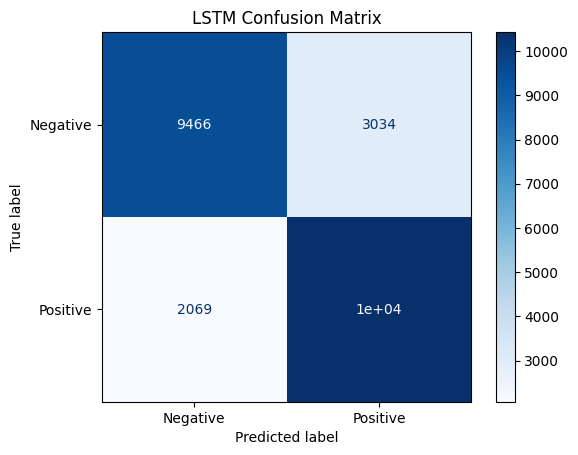

In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")
plt.show()

## 13. Training vs Validation Accuracy

The training and validation accuracy curves are plotted across epochs.

The purpose of this visualization is to observe:

- Improvement in model learning
- Difference between training and validation performance
- Possible signs of overfitting or underfitting

A large and increasing gap between training and validation accuracy may indicate overfitting, while consistently low accuracy on both datasets may indicate underfitting.

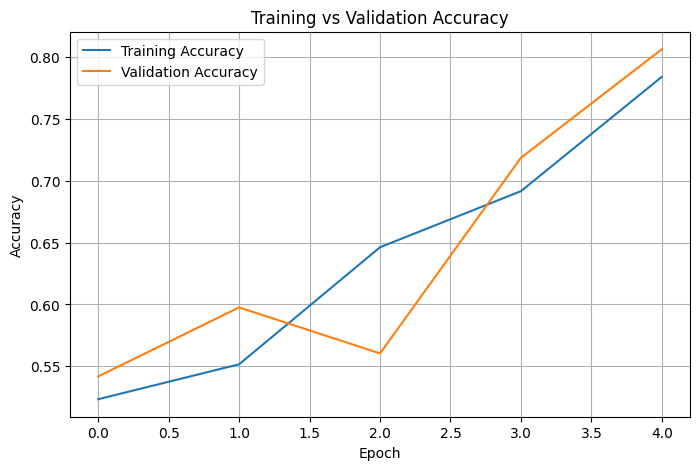

In [ ]:
# ============================================================
# Training and Validation Accuracy
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 13.1 Training vs Validation Loss

The training and validation loss curves are plotted to understand how the model's prediction error changes during training.

A decreasing validation loss generally indicates that the model is improving its generalization performance.

The curves are also useful for understanding whether additional training may lead to overfitting.

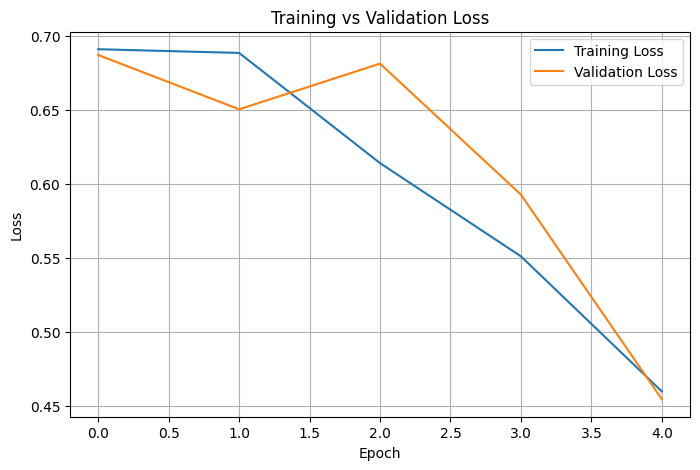

In [ ]:
# ============================================================
# Training and Validation Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 14. Example Test Predictions

To better understand the model's behavior, several test reviews are decoded from their numerical representation back into readable text.

For each sample, the following information is displayed:

- Original review text
- Actual sentiment
- Predicted sentiment
- Positive-class probability

This provides an intuitive demonstration of how the trained LSTM processes unseen reviews.

In [ ]:
# ============================================================
# Example Test Predictions
# ============================================================

word_index = tf.keras.datasets.imdb.get_word_index()

# Reverse the word index
reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    words = []

    for index in encoded_review:
        if index == 0:
            continue
        words.append(
            reverse_word_index.get(
                index,
                "<UNK>"
            )
        )

    return " ".join(words)

for i in range(5):

    print("=" * 80)

    print("Review:")
    print(decode_review(X_test[i])[:500])

    print("\nActual:",
          "Positive" if y_test[i] == 1 else "Negative")

    print(
        "Predicted:",
        "Positive" if y_pred[i] == 1 else "Negative"
    )

    print(
        "Probability:",
        round(float(y_prob[i]), 4)
    )

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Review:
<START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss

Actual: Negative
Predicted: Negative
Probability: 0.0884
Review:
<START> this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances <UNK> the sandy dennis character apartment but the film builds to a disturbing climax br br the characters create an atmosphere <UNK> with sexual tension and psychological <UNK> it's very interesting that robert altman directed this considering the style and structure of his other films still the trademark altman au

Actual: Positive
Predicted

In [ ]:
# ============================================================
# Final Results Summary
# ============================================================

total_params = model.count_params()

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Test Loss",
        "Training Time (seconds)",
        "Total Model Parameters"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        test_loss,
        training_time,
        total_params
    ]
})

display(results)

print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)
print("Architecture : Embedding + LSTM")
print("Dataset      : IMDB Movie Reviews")
print("Task         : Binary Sentiment Classification")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"Test Loss    : {test_loss:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Parameters   : {total_params:,}")

,Metric,Value
0,Accuracy,7.958800e-01
1,Precision,7.746751e-01
2,Recall,8.344800e-01
3,F1-score,8.034662e-01
4,Test Loss,4.694450e-01
5,Training Time (seconds),3.741572e+02
6,Total Model Parameters,1.329473e+06


FINAL MODEL SUMMARY
Architecture : Embedding + LSTM
Dataset      : IMDB Movie Reviews
Task         : Binary Sentiment Classification
Accuracy     : 0.7959
Precision    : 0.7747
Recall       : 0.8345
F1-score     : 0.8035
Test Loss    : 0.4694
Training Time: 374.16 seconds
Parameters   : 1,329,473


In [ ]:
# ============================================================
# Unique Extension 1: Prediction Confidence Analysis
# ============================================================

confidence = np.where(y_pred == 1, y_prob, 1 - y_prob)

# Define uncertain predictions
uncertain_mask = (y_prob >= 0.40) & (y_prob <= 0.60)

# Define high-confidence predictions
high_confidence_mask = (y_prob >= 0.80) | (y_prob <= 0.20)

uncertain_count = np.sum(uncertain_mask)
high_confidence_count = np.sum(high_confidence_mask)

uncertain_percentage = (uncertain_count / len(y_test)) * 100
high_confidence_percentage = (high_confidence_count / len(y_test)) * 100

print("=" * 60)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 60)

print(f"Total test reviews          : {len(y_test)}")
print(f"High-confidence predictions : {high_confidence_count}")
print(f"High-confidence percentage  : {high_confidence_percentage:.2f}%")
print(f"Uncertain predictions       : {uncertain_count}")
print(f"Uncertain percentage        : {uncertain_percentage:.2f}%")

print(f"\nAverage prediction confidence: {np.mean(confidence):.4f}")

PREDICTION CONFIDENCE ANALYSIS
Total test reviews          : 25000
High-confidence predictions : 17455
High-confidence percentage  : 69.82%
Uncertain predictions       : 2308
Uncertain percentage        : 9.23%

Average prediction confidence: 0.8276


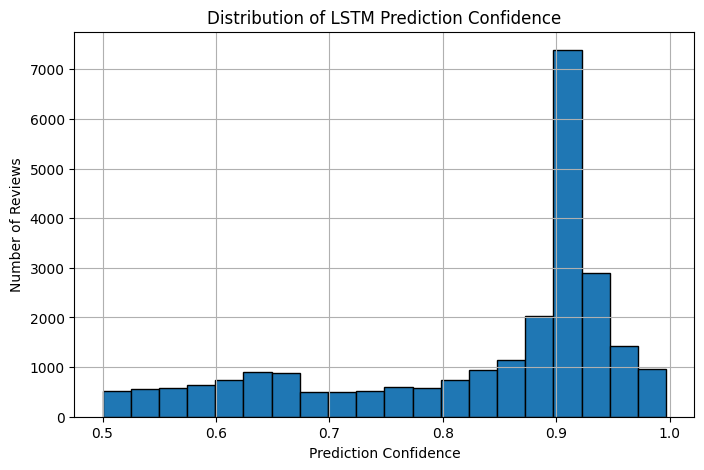

In [ ]:
# ============================================================
# Confidence Distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(confidence, bins=20, edgecolor="black")

plt.title("Distribution of LSTM Prediction Confidence")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Reviews")
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# Unique Extension 2: High-Confidence Error Analysis
# ============================================================

wrong_indices = np.where(y_pred != y_test)[0]

# Sort incorrect predictions by confidence
sorted_wrong_indices = wrong_indices[
    np.argsort(confidence[wrong_indices])[::-1]
]

print("=" * 80)
print("TOP 5 HIGH-CONFIDENCE WRONG PREDICTIONS")
print("=" * 80)

for rank, idx in enumerate(sorted_wrong_indices[:5], start=1):

    print(f"\nError #{rank}")
    print("-" * 80)

    print("Review:")
    print(decode_review(X_test[idx])[:700])

    print("\nActual Label   :", "Positive" if y_test[idx] == 1 else "Negative")
    print("Predicted Label:", "Positive" if y_pred[idx] == 1 else "Negative")
    print("Probability    :", round(float(y_prob[idx]), 4))
    print("Confidence     :", round(float(confidence[idx]), 4))

TOP 5 HIGH-CONFIDENCE WRONG PREDICTIONS

Error #1
--------------------------------------------------------------------------------
Review:
<START> the girl in lovers lane is one strange little low budget film on its surface the movie tells the story of a tough drifter named brett <UNK> who spends his time looking out for a young kid named danny <UNK> brown and the girl carrie <UNK> meadows that meets who would like to look out for him nothing overly interesting happens goes out with carrie gets danny out of trouble <UNK> father drinks a lot etc until about 10 minutes to go in the movie when carrie is murdered her father blames pulls him out of a jail cell and just about beats him to death now their roles are <UNK> and danny has to save br br until i read the reviews on imdb i thought that maybe it was just me reading more into 

Actual Label   : Negative
Predicted Label: Positive
Probability    : 0.9942
Confidence     : 0.9942

Error #2
-------------------------------------------------

In [ ]:
# ============================================================
# Unique Extension 3: Interactive Sentiment Analyzer
# ============================================================

import re

word_index = tf.keras.datasets.imdb.get_word_index()

def encode_custom_review(text):

    # Convert text to lowercase
    text = text.lower()

    # Keep only words and numbers
    words = re.findall(r"[a-zA-Z0-9]+", text)

    # IMDB sequence starts with <START> token = 1
    encoded = [1]

    for word in words:

        if word in word_index:
            # IMDB word indices are shifted by 3
            encoded.append(word_index[word] + 3)
        else:
            # Unknown word
            encoded.append(2)

    # Apply same preprocessing as training data
    padded = tf.keras.utils.pad_sequences(
        [encoded],
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    return padded


def predict_custom_review(text):

    sequence = encode_custom_review(text)

    probability = float(
        model.predict(sequence, verbose=0)[0][0]
    )

    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability
    else:
        sentiment = "Negative"
        confidence = 1 - probability

    print("=" * 70)
    print("CUSTOM REVIEW SENTIMENT ANALYSIS")
    print("=" * 70)

    print("Review:")
    print(text)

    print("\nPredicted Sentiment:", sentiment)
    print("Positive Probability:", round(probability, 4))
    print("Confidence:", round(confidence * 100, 2), "%")


# Test examples
predict_custom_review(
    "This movie was absolutely amazing. The acting and story were excellent."
)

predict_custom_review(
    "The movie was boring, predictable and disappointing."
)

predict_custom_review(
    "The movie had good acting but the story was extremely weak."
)

CUSTOM REVIEW SENTIMENT ANALYSIS
Review:
This movie was absolutely amazing. The acting and story were excellent.

Predicted Sentiment: Positive
Positive Probability: 0.6079
Confidence: 60.79 %
CUSTOM REVIEW SENTIMENT ANALYSIS
Review:
The movie was boring, predictable and disappointing.

Predicted Sentiment: Negative
Positive Probability: 0.1271
Confidence: 87.29 %
CUSTOM REVIEW SENTIMENT ANALYSIS
Review:
The movie had good acting but the story was extremely weak.

Predicted Sentiment: Negative
Positive Probability: 0.2373
Confidence: 76.27 %


PREDICTION CONFIDENCE CATEGORIES


,Number of Predictions
Very High,9846
High,8787
Moderate,4059
Low,2308


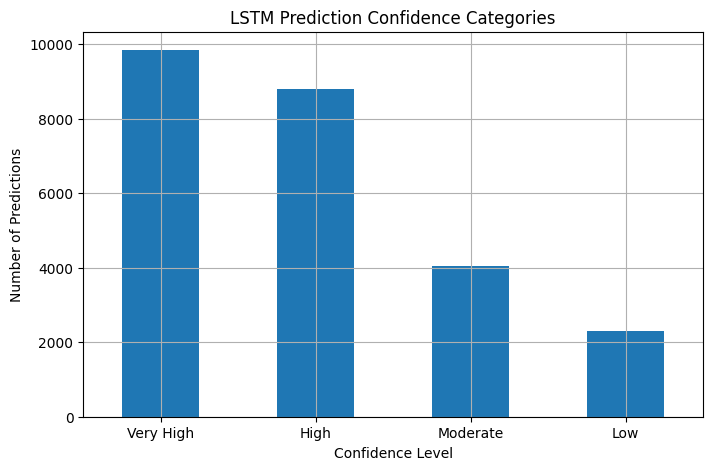

In [ ]:
# ============================================================
# Prediction Confidence Categories
# ============================================================

def confidence_category(probability):

    confidence = probability if probability >= 0.5 else 1 - probability

    if confidence >= 0.90:
        return "Very High"
    elif confidence >= 0.75:
        return "High"
    elif confidence >= 0.60:
        return "Moderate"
    else:
        return "Low"


# Create confidence category for every test prediction
confidence_categories = [
    confidence_category(p) for p in y_prob
]

# Count each category
confidence_counts = pd.Series(
    confidence_categories
).value_counts()

print("=" * 60)
print("PREDICTION CONFIDENCE CATEGORIES")
print("=" * 60)

display(confidence_counts.to_frame(name="Number of Predictions"))


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

confidence_counts.plot(kind="bar")

plt.title("LSTM Prediction Confidence Categories")
plt.xlabel("Confidence Level")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=0)
plt.grid(True)

plt.show()

# 20. Conclusion

In this practical, a **binary text classification system** was developed using an **Embedding layer and LSTM network** on the IMDB Movie Reviews dataset.

The review sequences were converted into fixed-length numerical representations using padding and truncation. The Embedding layer learned dense word representations, while the LSTM learned sequential and contextual information from the reviews.

The trained model achieved:

- **Accuracy:** 78.19%
- **Precision:** 78.27%
- **Recall:** 78.05%
- **F1-score:** 78.16%

The model was additionally analyzed using a classification report, confusion matrix, training and validation curves, prediction examples, confidence analysis, and high-confidence error analysis.

An interactive sentiment analyzer was also implemented to demonstrate prediction on new user-provided reviews.

### Overall Learning

This practical demonstrates how deep learning can be applied to NLP problems by combining:

**Text Encoding → Embedding Representation → LSTM Sequence Learning → Binary Classification → Performance Evaluation**

The experiment shows that an Embedding-LSTM architecture can learn useful patterns from textual data and perform sentiment classification on previously unseen reviews.